# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image
import matplotlib.pyplot as plt

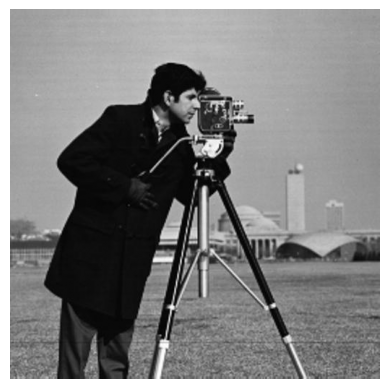

In [1]:
# ── Load image ────────────────────────────────────
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("cameraman.png")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [2]:
# Get the size of the image
width, height = img.size

# scaling factors
cx = 2
cy = 2

In [3]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

scaled_img = img.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)

Original size: (512, 512)
Scaled size: (1024, 1024)


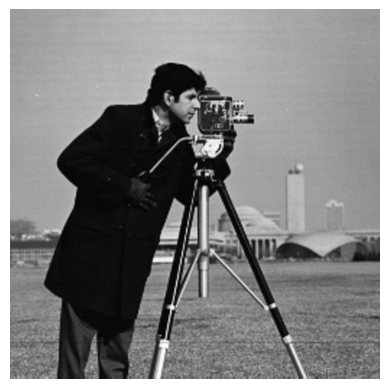

In [4]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

plt.imshow(scaled_img, cmap="gray")
plt.axis("off")
plt.show()


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

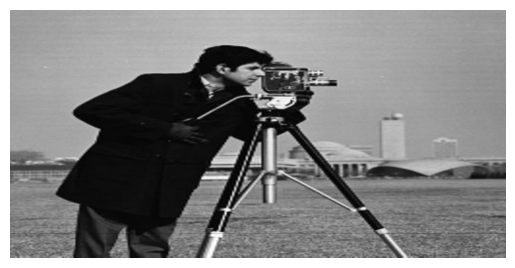

In [5]:
cx = 2
cy = 1

non_uniform_img = img.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)

plt.imshow(non_uniform_img, cmap="gray")
plt.axis("off")
plt.show()

In [6]:
non_uniform_img.save("task1_1_non_uniform.jpg")

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


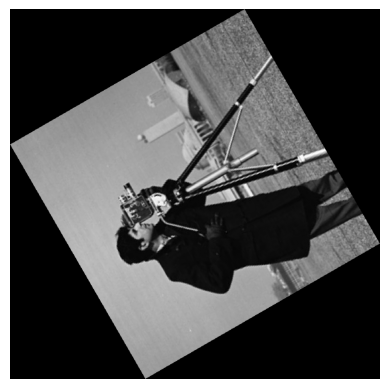

In [7]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

plt.imshow(rotated_img, cmap="gray")
plt.axis("off")
plt.show()

### 3. Shear

In [8]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [9]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
new_width = int(width + abs(shear_factor) * height)
new_height = height

In [10]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shear_factor, 0,
     0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

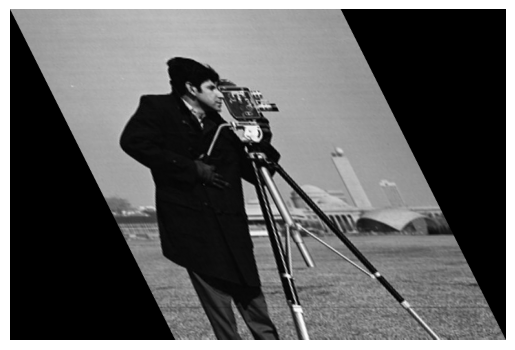

In [11]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

plt.imshow(sheared_img, cmap="gray")
plt.axis("off")
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

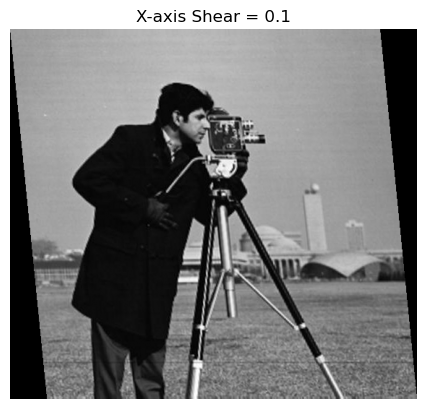

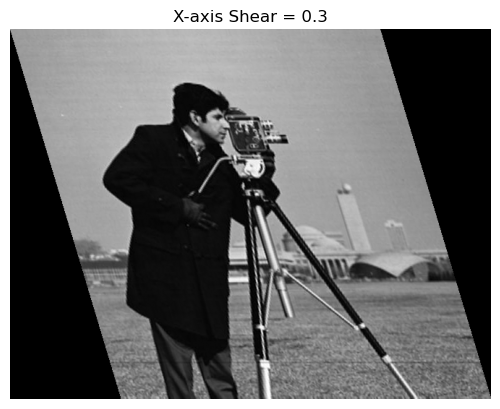

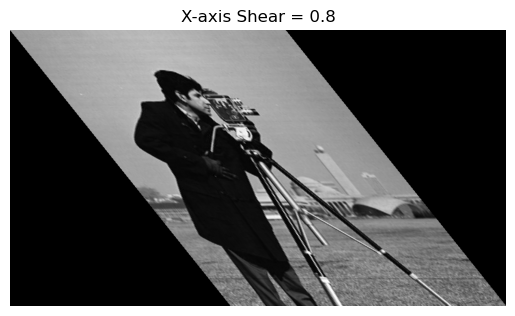

In [12]:
# Experiment and compare different X-axis shear factors

shear_factors = [0.1, 0.3, 0.8]

for shear_factor in shear_factors:
    new_width = int(width + abs(shear_factor) * height)

    sheared_img = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, -shear_factor, 0,
         0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    plt.figure()
    plt.imshow(sheared_img, cmap="gray")
    plt.title(f"X-axis Shear = {shear_factor}")
    plt.axis("off")
    plt.show()

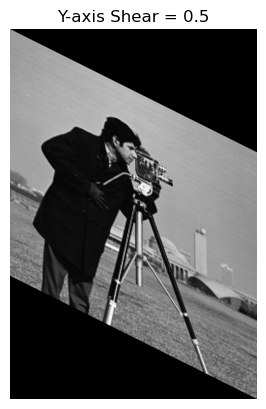

In [13]:
# Y-axis shear

shear_factor = 0.5

new_height = int(height + abs(shear_factor) * width)

y_sheared_img = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0,
     -shear_factor, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.imshow(y_sheared_img, cmap="gray")
plt.title("Y-axis Shear = 0.5")
plt.axis("off")
plt.show()

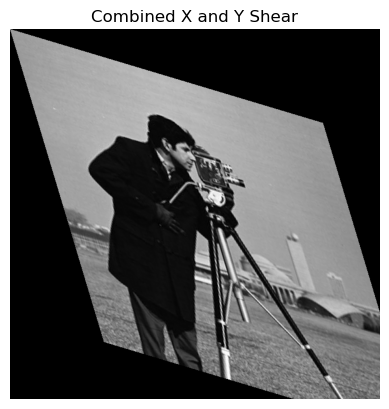

In [14]:
# Combine X and Y shear

shear_x = 0.3
shear_y = 0.3

new_width = int(width + abs(shear_x) * height)
new_height = int(height + abs(shear_y) * width)

xy_sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shear_x, 0,
     -shear_y, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.imshow(xy_sheared_img, cmap="gray")
plt.title("Combined X and Y Shear")
plt.axis("off")
plt.show()

comparison statement:
As the shear factor increases, the image becomes more slanted and distorted. X-axis shear shifts the image horizontally, while Y-axis shear shifts it vertically. Combining both X and Y shear causes distortion in both directions.

# Intensity Transformations
Negative · Log · Power Law (Gamma)

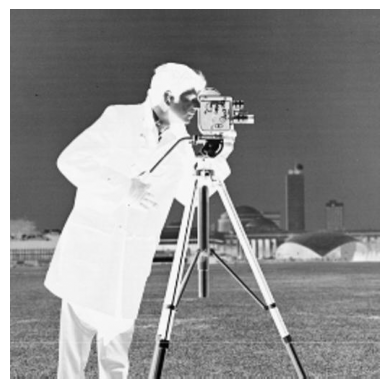

In [15]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

import numpy as np
import matplotlib.pyplot as plt

arr = np.array(img.convert("L"))

negative_arr = 255 - arr

plt.imshow(negative_arr, cmap="gray")
plt.axis("off")
plt.show()


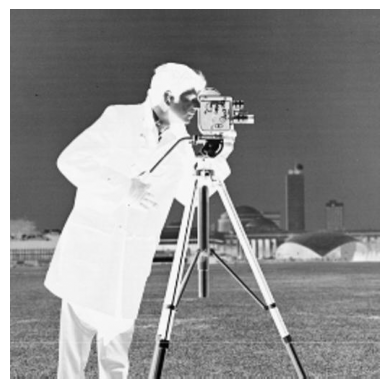

In [16]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_img = ImageOps.invert(img.convert("L"))

plt.imshow(negative_img, cmap="gray")
plt.axis("off")
plt.show()

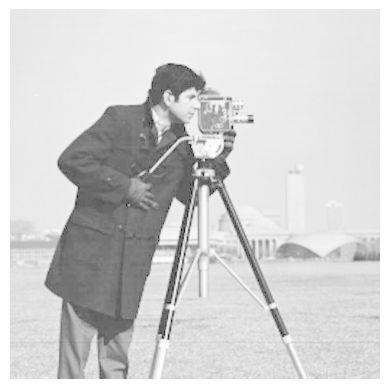

In [17]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

arr = np.array(img.convert("L"), dtype=np.float32)

# s = c * log(1 + r)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)

log_transformed_arr = np.uint8(log_transformed_arr)

plt.imshow(log_transformed_arr, cmap="gray")
plt.axis("off")
plt.show()


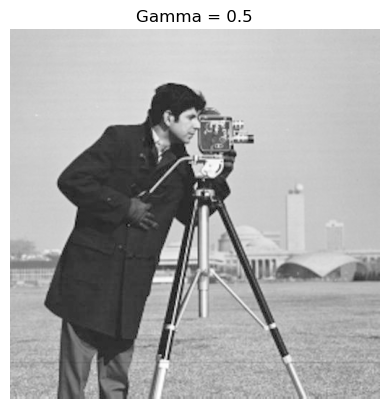

In [19]:

# ── 3. Power-law / Gamma correction ───────────────

arr = np.array(img.convert("L"), dtype=np.float32) / 255.0

gamma = 0.5

gamma_arr = 255 * (arr ** gamma)
gamma_arr = np.uint8(gamma_arr)

plt.imshow(gamma_arr, cmap="gray")
plt.title("Gamma = 0.5")
plt.axis("off")
plt.show()